## Importing all the needed libraries

In [93]:
!pip install scikit-plot
!pip -q install -U scipy scikit-plot


183924.36s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


183930.38s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [94]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [95]:
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score,
)
#from scikitplot.metrics import plot_roc, plot_precision_recall


In [96]:
#importing the dataset_cleaned and doing a sanity check on the "Rating" column, which is our target variable
data = pd.read_csv('dataset/DM1_game_dataset_cleaned.csv')
#printing all the columns of the dataset
print(data.columns)
data["Rating"].dtype
data["Rating"].head(10)



Index(['Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
       'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions',
       'NumImplementations', 'IsReimplementation', 'Kickstarted', 'Rating',
       'HasFamily', 'Category', 'Rank', 'EngagementLevel'],
      dtype='object')


0       Low
1    Medium
2      High
3       Low
4    Medium
5       Low
6      High
7       Low
8       Low
9    Medium
Name: Rating, dtype: object

In [ ]:
#setting the x and y variables
X_df = data.drop(columns=["Rating", "Name"])
y = data["Rating"].values

In [98]:
#quick controls on the features
feature_summary = []

for col in X_df.columns:
    s = X_df[col]
    
    feature_summary.append({
        "feature": col,
        "dtype": s.dtype,
        "missing_rate": s.isna().mean(),
        "n_unique": s.nunique(),
        "dominant_value_share": s.value_counts(normalize=True).iloc[0]
                                if s.nunique() > 0 else np.nan
    })

feature_summary = pd.DataFrame(feature_summary).sort_values("feature")
feature_summary

,feature,dtype,missing_rate,n_unique,dominant_value_share
12,Category,object,0.0,9,0.511129
14,EngagementLevel,float64,0.0,3514,0.006856
1,GameWeight,float64,0.0,3886,0.115362
11,HasFamily,int64,0.0,2,0.697335
9,IsReimplementation,int64,0.0,2,0.884364
10,Kickstarted,int64,0.0,2,0.847388
3,MaxPlayers,int64,0.0,53,0.321358
5,MfgAgeRec,int64,0.0,20,0.251063
4,MfgPlaytime,int64,0.0,120,0.176151
2,MinPlayers,int64,0.0,10,0.687006


In [99]:
#fixing YearPublished
if 'YearPublished' in X_df.columns:
    current_year = X_df['YearPublished'].max()
    X_df['YearPublished'] = current_year - X_df['YearPublished']

In [100]:
FINAL_FEATURES = [
    'YearPublished',
    'GameWeight',
    'MinPlayers',
    'MaxPlayers',
    'MfgPlaytime',
    'MfgAgeRec',
    'NumAlternates',
    'NumExpansions',
    'NumImplementations',
    'IsReimplementation',
    'Kickstarted',
    'HasFamily',
    'Category',
    'EngagementLevel',
    'Rank'
]

X_df = X_df[FINAL_FEATURES]



In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_df, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [102]:
#checking the distribution of the target variable in train and test sets
import numpy as np

def show_class_shares(y_vec, name="y"):
    labels, counts = np.unique(y_vec, return_counts=True)
    shares = counts / counts.sum()
    print(f"{name} class shares:")
    for lab, c, s in zip(labels, counts, shares):
        print(f"  class={lab}: count={c}, share={s:.4f}")
    print()

show_class_shares(y, "y (full)")
show_class_shares(y_train, "y_train")
show_class_shares(y_test, "y_test")


y (full) class shares:
  class=High: count=5000, share=0.2285
  class=Low: count=7241, share=0.3310
  class=Medium: count=9638, share=0.4405

y_train class shares:
  class=High: count=3500, share=0.2285
  class=Low: count=5069, share=0.3310
  class=Medium: count=6746, share=0.4405

y_test class shares:
  class=High: count=1500, share=0.2285
  class=Low: count=2172, share=0.3309
  class=Medium: count=2892, share=0.4406



In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# individua automaticamente le colonne
num_features = X_train.select_dtypes(include="number").columns
cat_features = X_train.select_dtypes(exclude="number").columns  

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)


In [104]:
X_train_pre = preprocess.fit_transform(X_train)  # fit SOLO sul train
X_test_pre  = preprocess.transform(X_test)       # transform sul test

print("X_train_pre shape:", X_train_pre.shape)
print("X_test_pre shape:", X_test_pre.shape)


X_train_pre shape: (15315, 23)
X_test_pre shape: (6564, 23)


In [105]:
# KNN with uniform weights
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

knn_base = KNeighborsClassifier(n_neighbors=5, weights="uniform", p=2)

knn_base.fit(X_train_pre, y_train)

y_pred_base = knn_base.predict(X_test_pre)

print("BASE MODEL")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("F1 macro:", f1_score(y_test, y_pred_base, average="macro"))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_base))
print("\nClassification report:\n", classification_report(y_test, y_pred_base))



BASE MODEL
Accuracy: 0.556672760511883
F1 macro: 0.5565322042757666

Confusion matrix:
 [[ 807  136  557]
 [ 152 1332  688]
 [ 534  843 1515]]

Classification report:
               precision    recall  f1-score   support

        High       0.54      0.54      0.54      1500
         Low       0.58      0.61      0.59      2172
      Medium       0.55      0.52      0.54      2892

    accuracy                           0.56      6564
   macro avg       0.56      0.56      0.56      6564
weighted avg       0.56      0.56      0.56      6564



In [106]:
#KNN with distance weights
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

knn_base = KNeighborsClassifier(n_neighbors=5, weights="distance", p=2)

knn_base.fit(X_train_pre, y_train)

y_pred_base = knn_base.predict(X_test_pre)

print("BASE MODEL")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("F1 macro:", f1_score(y_test, y_pred_base, average="macro"))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_base))
print("\nClassification report:\n", classification_report(y_test, y_pred_base))

BASE MODEL
Accuracy: 0.5659658744667886
F1 macro: 0.5636104687272407

Confusion matrix:
 [[ 762  122  616]
 [ 108 1283  781]
 [ 452  770 1670]]

Classification report:
               precision    recall  f1-score   support

        High       0.58      0.51      0.54      1500
         Low       0.59      0.59      0.59      2172
      Medium       0.54      0.58      0.56      2892

    accuracy                           0.57      6564
   macro avg       0.57      0.56      0.56      6564
weighted avg       0.57      0.57      0.57      6564



In [ ]:

# KNN + GridSearchCV maximizing F1 macro
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": list(range(3, 41, 2)),
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # 1=Manhattan, 2=Euclidean
}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_pre, y_train)

best_knn = grid.best_estimator_
print("\nBEST MODEL (CV)")
print("Best params:", grid.best_params_)
print("Best CV F1 macro:", grid.best_score_)

y_pred_best = best_knn.predict(X_test_pre)

print("\nTEST SET PERFORMANCE (Best KNN)")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1 macro:", f1_score(y_test, y_pred_best, average="macro"))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification report:\n", classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 76 candidates, totalling 380 fits


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - to python to disable frozen modules.
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0


BEST MODEL (CV)
Best params: {'n_neighbors': 39, 'p': 1, 'weights': 'distance'}
Best CV F1 macro: 0.6028354036085172

TEST SET PERFORMANCE (Best KNN)
Accuracy: 0.6081657525898843
F1 macro: 0.6005388985510048

Confusion matrix:
 [[ 701   94  705]
 [  32 1380  760]
 [ 293  688 1911]]

Classification report:
               precision    recall  f1-score   support

        High       0.68      0.47      0.56      1500
         Low       0.64      0.64      0.64      2172
      Medium       0.57      0.66      0.61      2892

    accuracy                           0.61      6564
   macro avg       0.63      0.59      0.60      6564
weighted avg       0.62      0.61      0.61      6564



Exception ignored in: <function ResourceTracker.__del__ at 0x11887a480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x108e46480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1064e2480>
Traceback (most recent call last

Fitting 10 folds for each of 320 candidates, totalling 3200 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call



BEST MODEL FROM GRIDSEARCH (CV)
Best k: 46
Best weights: distance
Best p: 1
Best CV F1 macro: 0.603551783748906


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.54005078 0.52814765 0.52814765        nan 0.54005078
 0.51187386 0.52814765        nan 0.56276169 0.54020838 0.54740421
        nan 0.56924213 0.57098028 0.56060774        nan 0.57723721
 0.55796945 0.56297846        nan 0.58263054 0.57143647 0.57128377
        nan 0.5902325  0.56884343 0.57116992        nan 0.58870439
 0.57502385 0.57318716        nan 0.59305356 0.57422635 0.57609224
        nan 0.59467457 0.57989757 0.57747847        nan 0.59446115
 0.57654282 0.57881061        nan 0.59510368 0.58139793 0.58002058
        nan 0.59599522 0.57734251 0.58199056        nan 0.59521046
 0.57914737 0.58295678        nan 0.59863605 0.57747226 0.5838774
        nan 0.59725962 0.57924174 0.58348278        nan 0.59872175
 0.57977829 0.58301761        nan 0.59972171 0.57989674 0.58369518
        nan 0.60063794 0.57964688 0.58352035        

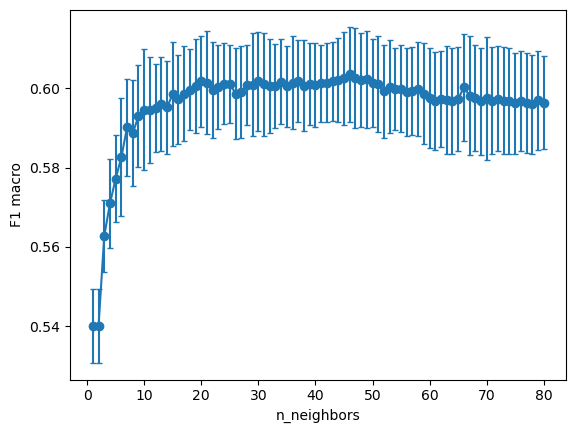


BEST k FROM CURVE
Best k (curve): 46
CV F1 macro at best k: 0.603551783748906

TEST SET PERFORMANCE (Best KNN)
Accuracy: 0.6113650213284583
F1 macro: 0.6034191409896614
Confusion matrix:
 [[ 700  100  700]
 [  30 1375  767]
 [ 273  681 1938]]
Classification report:
               precision    recall  f1-score   support

        High       0.70      0.47      0.56      1500
         Low       0.64      0.63      0.64      2172
      Medium       0.57      0.67      0.62      2892

    accuracy                           0.61      6564
   macro avg       0.63      0.59      0.60      6564
weighted avg       0.62      0.61      0.61      6564



Exception ignored in: <function ResourceTracker.__del__ at 0x105e46480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1050ca480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x11075e480>
Traceback (most recent call last

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# ----------------------------
# 1) Cross-validation setup
# ----------------------------
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ----------------------------
# 2) Hyperparameter grid
# ----------------------------
param_grid = {
    "n_neighbors": list(range(1, 81)),
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # 1=Manhattan, 2=Euclidean (Minkowski p)
}

# ----------------------------
# 3) GridSearchCV maximizing F1 macro
# ----------------------------
grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv10,
    n_jobs=-1,
    return_train_score=False,
    verbose=1
)

grid.fit(X_train_pre, y_train)

# =========================================================
# (1) BEST MODEL FROM GRIDSEARCH (overall best configuration)
# =========================================================
best_k_grid = int(grid.best_params_["n_neighbors"])
best_weights = grid.best_params_["weights"]
best_p = int(grid.best_params_["p"])
best_score_grid = grid.best_score_

print("\nBEST MODEL FROM GRIDSEARCH (CV)")
print("Best k:", best_k_grid)
print("Best weights:", best_weights)
print("Best p:", best_p)
print("Best CV F1 macro:", best_score_grid)

# ----------------------------
# 4) Build CV curve: F1 macro vs k (best config per k)
# ----------------------------
res = pd.DataFrame(grid.cv_results_)

# For each k, retain the best-performing combination of (weights, p) by mean CV F1 macro
idx = res.groupby("param_n_neighbors")["mean_test_score"].idxmax()
best_per_k = res.loc[idx].sort_values("param_n_neighbors")

k_vals = best_per_k["param_n_neighbors"].astype(int).to_numpy()
mean_f1 = best_per_k["mean_test_score"].to_numpy()
std_f1  = best_per_k["std_test_score"].to_numpy()

plt.figure()
plt.errorbar(k_vals, mean_f1, yerr=std_f1, fmt='-o', capsize=2)
plt.xlabel("n_neighbors")
plt.ylabel("F1 macro")
plt.show()

# =========================================================
# (2) BEST k FROM THE CURVE (peak of mean CV F1 macro)
# =========================================================
idx_best_k_curve = best_per_k["mean_test_score"].idxmax()
best_k_curve = int(best_per_k.loc[idx_best_k_curve, "param_n_neighbors"])
best_score_curve = float(best_per_k.loc[idx_best_k_curve, "mean_test_score"])

print("\nBEST k FROM CURVE")
print("Best k (curve):", best_k_curve)
print("CV F1 macro at best k:", best_score_curve)

# ----------------------------
# 5) Test set evaluation (best estimator)
# ----------------------------
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test_pre)

print("\nTEST SET PERFORMANCE (Best KNN)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


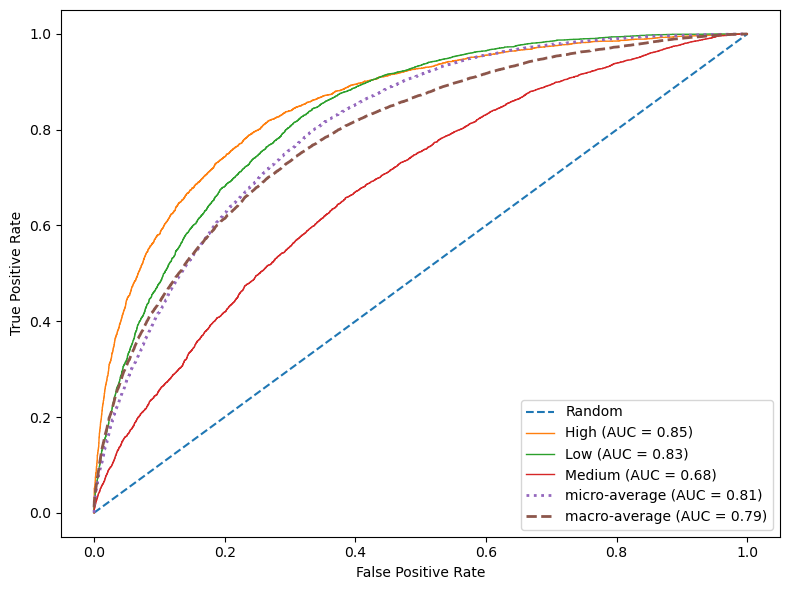

In [127]:
#plotting ROC curve 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# ---------------------------------------
# INPUT RICHIESTI
# ---------------------------------------
# X_train_pre : features preprocessate (train)
# y_train     : etichette ("High", "Low", "Medium")
# best_knn    : modello KNN ottimizzato (grid.best_estimator_)

class_order = ["High", "Low", "Medium"]

# ---------------------------------------
# CV predicted probabilities (TRAIN)
# ---------------------------------------
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

y_proba_cv = cross_val_predict(
    clone(best_knn),
    X_train_pre,
    y_train,
    cv=cv10,
    method="predict_proba",
    n_jobs=-1
)

# allineo colonne proba all’ordine delle classi
proba_cols = clone(best_knn).fit(X_train_pre, y_train).classes_
idx = [list(proba_cols).index(c) for c in class_order]
y_proba_cv = y_proba_cv[:, idx]

# binarizzazione one-vs-rest
y_train_arr = np.array(y_train)
y_bin = np.column_stack([(y_train_arr == c).astype(int) for c in class_order])

# ---------------------------------------
# ROC per classe
# ---------------------------------------
fpr = {}
tpr = {}
roc_auc = {}

for i, c in enumerate(class_order):
    fpr[c], tpr[c], _ = roc_curve(y_bin[:, i], y_proba_cv[:, i])
    roc_auc[c] = auc(fpr[c], tpr[c])

# ---------------------------------------
# Micro-average ROC
# ---------------------------------------
fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_proba_cv.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# ---------------------------------------
# Macro-average ROC
# ---------------------------------------
all_fpr = np.unique(np.concatenate([fpr[c] for c in class_order]))
mean_tpr = np.zeros_like(all_fpr)

for c in class_order:
    mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])

mean_tpr /= len(class_order)
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ---------------------------------------
# Plot
# ---------------------------------------
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

for c in class_order:
    plt.plot(fpr[c], tpr[c], linewidth=1,
             label=f"{c} (AUC = {roc_auc[c]:.2f})")

plt.plot(
    fpr["micro"], tpr["micro"],
    linestyle=":", linewidth=2,
    label=f"micro-average (AUC = {roc_auc['micro']:.2f})"
)

plt.plot(
    fpr["macro"], tpr["macro"],
    linestyle="--", linewidth=2,
    label=f"macro-average (AUC = {roc_auc['macro']:.2f})"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


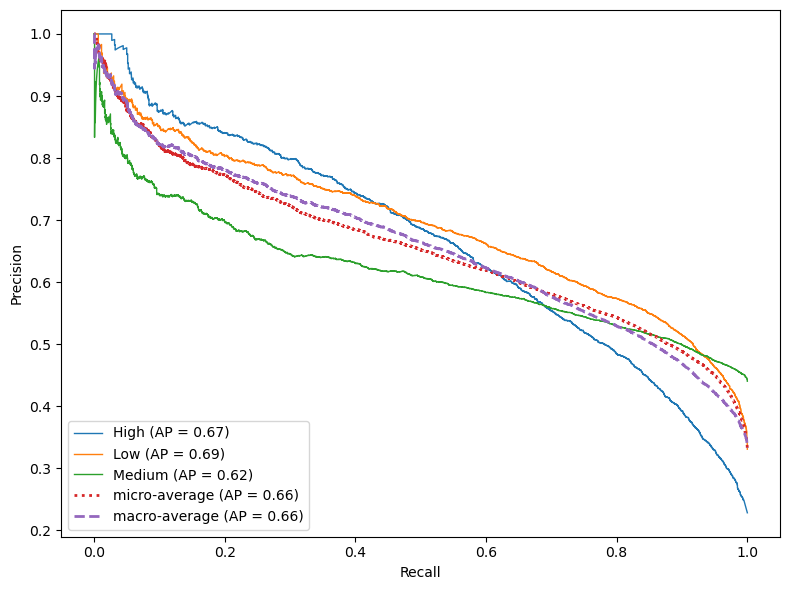

In [128]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve, average_precision_score

# ---------------------------------------
# INPUT RICHIESTI
# ---------------------------------------
# X_train_pre : features preprocessate (train)
# y_train     : etichette ("High", "Low", "Medium")
# best_knn    : modello KNN ottimizzato (grid.best_estimator_)

class_order = ["High", "Low", "Medium"]

# ---------------------------------------
# CV predicted probabilities (TRAIN)
# ---------------------------------------
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

y_proba_cv = cross_val_predict(
    clone(best_knn),
    X_train_pre,
    y_train,
    cv=cv10,
    method="predict_proba",
    n_jobs=-1
)

# allineo colonne proba all’ordine delle classi
proba_cols = clone(best_knn).fit(X_train_pre, y_train).classes_
idx = [list(proba_cols).index(c) for c in class_order]
y_proba_cv = y_proba_cv[:, idx]

# binarizzazione one-vs-rest
y_train_arr = np.array(y_train)
y_bin = np.column_stack([(y_train_arr == c).astype(int) for c in class_order])

# ---------------------------------------
# Precision–Recall per classe
# ---------------------------------------
precision = {}
recall = {}
avg_precision = {}

for i, c in enumerate(class_order):
    precision[c], recall[c], _ = precision_recall_curve(
        y_bin[:, i], y_proba_cv[:, i]
    )
    avg_precision[c] = average_precision_score(
        y_bin[:, i], y_proba_cv[:, i]
    )

# ---------------------------------------
# Micro-average Precision–Recall
# ---------------------------------------
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_bin.ravel(), y_proba_cv.ravel()
)
avg_precision["micro"] = average_precision_score(
    y_bin, y_proba_cv, average="micro"
)

# ---------------------------------------
# Macro-average Precision–Recall
# ---------------------------------------
all_recall = np.unique(np.concatenate([recall[c] for c in class_order]))
mean_precision = np.zeros_like(all_recall)

for c in class_order:
    mean_precision += np.interp(all_recall, recall[c][::-1], precision[c][::-1])

mean_precision /= len(class_order)
precision["macro"] = mean_precision
recall["macro"] = all_recall
avg_precision["macro"] = average_precision_score(
    y_bin, y_proba_cv, average="macro"
)

# ---------------------------------------
# Plot
# ---------------------------------------
plt.figure(figsize=(8, 6))

for c in class_order:
    plt.plot(
        recall[c], precision[c], linewidth=1,
        label=f"{c} (AP = {avg_precision[c]:.2f})"
    )

plt.plot(
    recall["micro"], precision["micro"],
    linestyle=":", linewidth=2,
    label=f"micro-average (AP = {avg_precision['micro']:.2f})"
)

plt.plot(
    recall["macro"], precision["macro"],
    linestyle="--", linewidth=2,
    label=f"macro-average (AP = {avg_precision['macro']:.2f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


In [136]:
#repeated Holdout validation
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import clone
from sklearn.metrics import f1_score, accuracy_score

N = 50
test_size = 0.30

sss = StratifiedShuffleSplit(n_splits=N, test_size=test_size, random_state=42)

f1_scores = []
acc_scores = []

for train_idx, test_idx in sss.split(X_df, y):
    # split (manteniamo il tuo stile: X_train/X_test + preprocess fit SOLO sul train)
    X_train, X_test = X_df.iloc[train_idx], X_df.iloc[test_idx] if hasattr(X_df, "iloc") else (X_df[train_idx], X_df[test_idx])
    y_train, y_test = y[train_idx], y[test_idx]

    # fit-transform sul train, transform sul test (NO leakage)
    pre = clone(preprocess)
    X_train_pre = pre.fit_transform(X_train)
    X_test_pre  = pre.transform(X_test)

    # fit classifier
    clf = clone(best_knn)
    clf.fit(X_train_pre, y_train)

    # predict + metriche
    y_pred = clf.predict(X_test_pre)

    f1_scores.append(f1_score(y_test, y_pred, average="macro"))
    acc_scores.append(accuracy_score(y_test, y_pred))

print(f"Repeated Stratified Holdout (N={N}, test_size={test_size})")
print(f"F1 macro: mean={np.mean(f1_scores):.4f}, std={np.std(f1_scores):.4f}")
print(f"Accuracy: mean={np.mean(acc_scores):.4f}, std={np.std(acc_scores):.4f}")



Repeated Stratified Holdout (N=50, test_size=0.3)
F1 macro: mean=0.6038, std=0.0052
Accuracy: mean=0.6125, std=0.0048


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

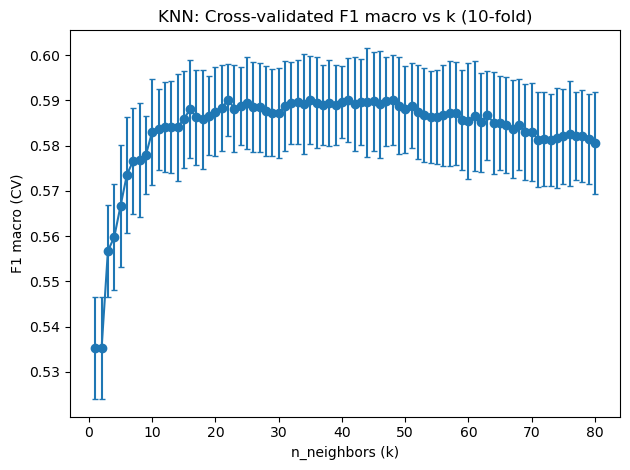

Best k (by CV F1 macro): 22
Best mean CV F1 macro: 0.5901601448583372


In [137]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

k_values = range(1, 81)
mean_scores, std_scores = [], []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k, weights="distance", p=2)  # esempio: fissi una config
    scores = cross_val_score(clf, X_train_pre, y_train, cv=cv10, scoring="f1_macro", n_jobs=-1)
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())

plt.figure()
plt.errorbar(list(k_values), mean_scores, yerr=std_scores, fmt='-o', capsize=2)
plt.xlabel("n_neighbors (k)")
plt.ylabel("F1 macro (CV)")
plt.title("KNN: Cross-validated F1 macro vs k (10-fold)")
plt.tight_layout()
plt.show()

best_k = list(k_values)[int(np.argmax(mean_scores))]
print("Best k (by CV F1 macro):", best_k)
print("Best mean CV F1 macro:", max(mean_scores))


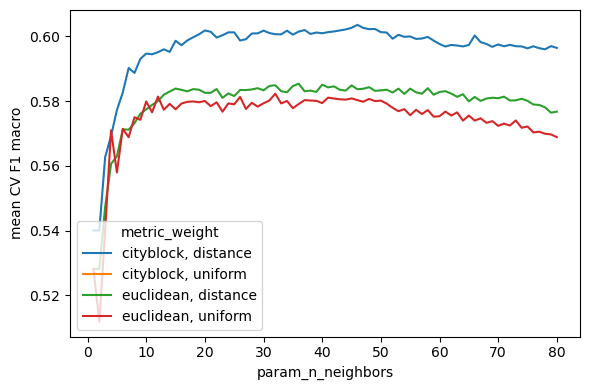

Exception ignored in: <function ResourceTracker.__del__ at 0x107a46480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103732480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103d46480>
Traceback (most recent call last

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# grid è il tuo GridSearchCV già fit-tato
res = pd.DataFrame(grid.cv_results_)

# mappa p -> nome metrica (opzionale, solo per legenda leggibile)
metric_map = {1: "cityblock", 2: "euclidean"}
res["metric_name"] = res["param_p"].astype(int).map(metric_map)

# crea etichetta "metric, weight" come nel grafico esempio
res["metric_weight"] = res["metric_name"] + ", " + res["param_weights"].astype(str)

plt.figure(figsize=(6, 4))

for label, g in res.groupby("metric_weight"):
    g_sorted = g.sort_values("param_n_neighbors")
    plt.plot(g_sorted["param_n_neighbors"].astype(int),
             g_sorted["mean_test_score"],
             label=label)

plt.xlabel("param_n_neighbors")
plt.ylabel("mean CV F1 macro")
plt.legend(title="metric_weight", loc="lower left")
plt.tight_layout()
plt.show()


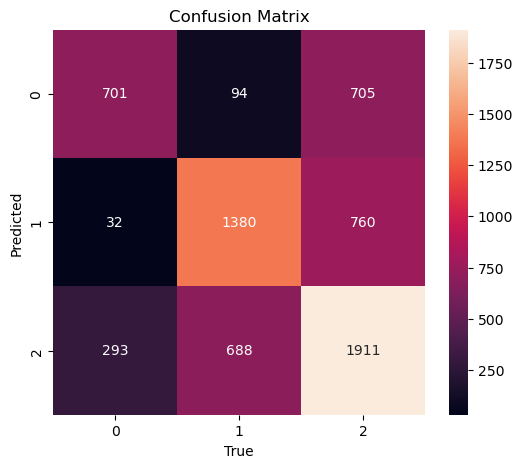

Exception ignored in: <function ResourceTracker.__del__ at 0x106dfa480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1048ca480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103726480>
Traceback (most recent call last

In [ ]:
#creating a confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)  
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cbar=True)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Confusion Matrix")
plt.show()


<Figure size 700x500 with 0 Axes>

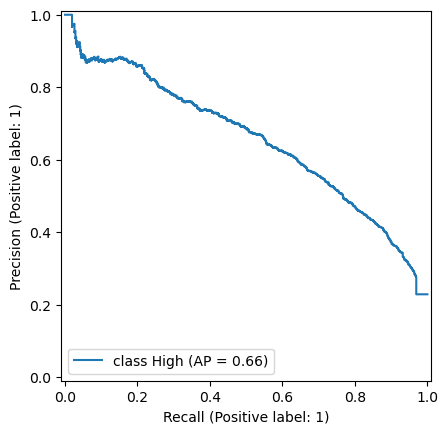

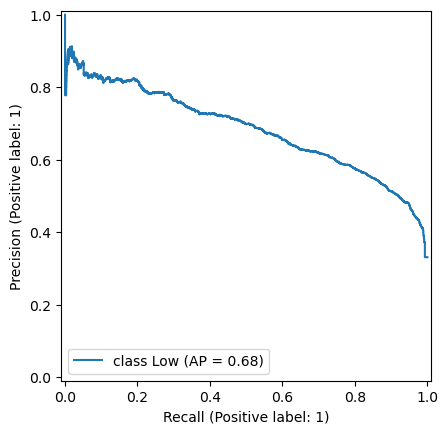

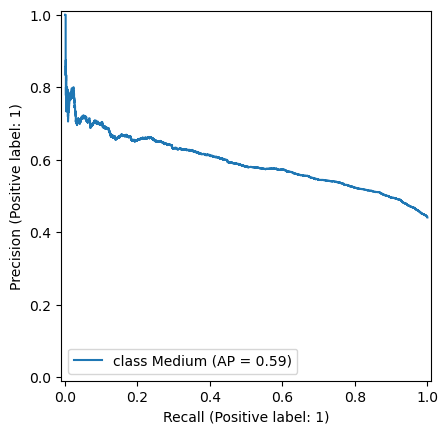

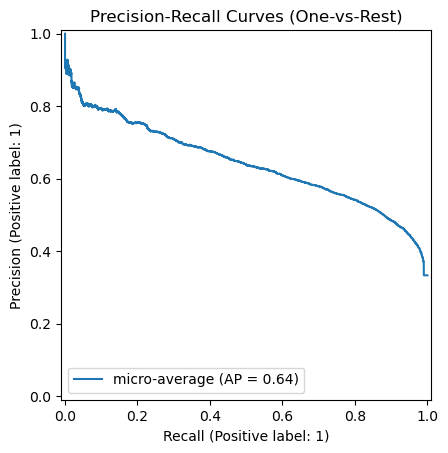

In [109]:
#analysis ROC
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import PrecisionRecallDisplay
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
Y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(7, 5))

# PR per ogni classe
for i, c in enumerate(classes):
    PrecisionRecallDisplay.from_predictions(
        Y_test_bin[:, i],
        y_proba[:, i],
        name=f"class {c}"
    )

# Micro-average PR
PrecisionRecallDisplay.from_predictions(
    Y_test_bin.ravel(),
    y_proba.ravel(),
    name="micro-average"
)

plt.title("Precision-Recall Curves (One-vs-Rest)")
plt.show()




In [ ]:
#Repeated Holdout validation


In [111]:
# cross validation 
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

k = 10
clf = KNeighborsClassifier(n_neighbors=5, weights="uniform", p=2)

scores = cross_val_score(clf, X_train_pre, y_train, cv=k, scoring="accuracy")
print("CV accuracy mean:", scores.mean(), "std:", scores.std())
print("CV error estimate:", 1 - scores.mean())

scores_f1 = cross_val_score(clf, X_train_pre, y_train, cv=k, scoring="f1_macro")
print("CV f1_macro mean:", scores_f1.mean(), "std:", scores_f1.std())


CV accuracy mean: 0.5559231922342945 std: 0.010580385753848688
CV error estimate: 0.44407680776570546
CV f1_macro mean: 0.5558564072004988 std: 0.01044050378887422


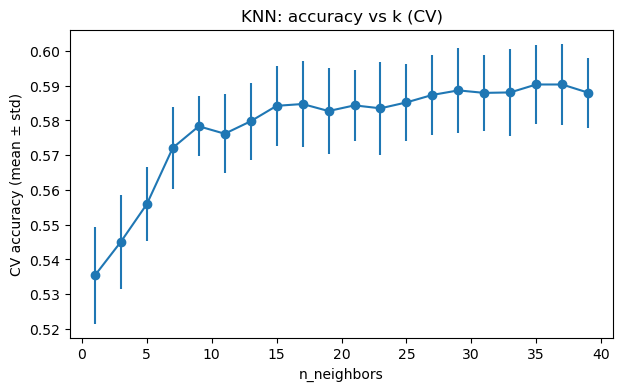

In [112]:
#tuning
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

n_neighbors_list = list(range(1, 41, 2))
avg_scores = []
std_scores = []

for n in n_neighbors_list:
    clf = KNeighborsClassifier(n_neighbors=n, weights="uniform", p=2)
    scores = cross_val_score(clf, X_train_pre, y_train, cv=10, scoring="accuracy")
    avg_scores.append(scores.mean())
    std_scores.append(scores.std())

plt.figure(figsize=(7, 4))
plt.errorbar(n_neighbors_list, avg_scores, yerr=std_scores, marker="o")
plt.xlabel("n_neighbors")
plt.ylabel("CV accuracy (mean ± std)")
plt.title("KNN: accuracy vs k (CV)")
plt.show()


Fitting 5 folds for each of 88 candidates, totalling 440 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call


Best params: {'metric': 'cityblock', 'n_neighbors': 41, 'weights': 'distance'}
Best CV score: 0.6031296514837224


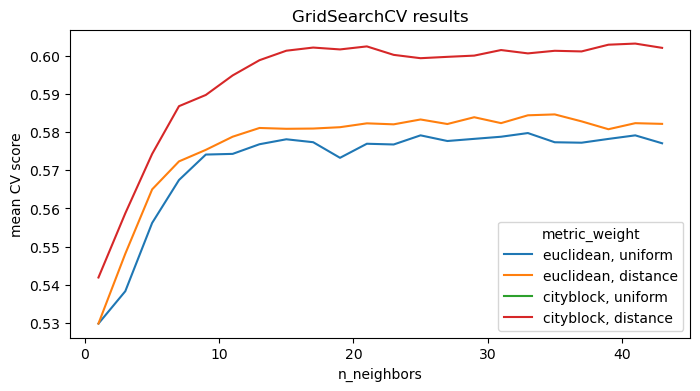

In [113]:
#another GridSearchCV
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

param_grid_prof = {
    "n_neighbors": list(range(1, 45, 2)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "cityblock"],  
}

cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)

grid_prof = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_prof,
    scoring="f1_macro",          
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_prof.fit(X_train_pre, y_train)
print("Best params:", grid_prof.best_params_)
print("Best CV score:", grid_prof.best_score_)

results = pd.DataFrame(grid_prof.cv_results_)
results["metric_weight"] = results["param_metric"].astype(str) + ", " + results["param_weights"].astype(str)

plt.figure(figsize=(8, 4))
sns.lineplot(data=results, x="param_n_neighbors", y="mean_test_score", hue="metric_weight")
plt.xlabel("n_neighbors")
plt.ylabel("mean CV score")
plt.title("GridSearchCV results")
plt.show()


In [114]:
# KNN + GridSearchCV maximizing balanced accuracy
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold


param_grid = {
    "n_neighbors": list(range(3, 41, 2)),
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # 1=Manhattan, 2=Euclidean
}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=RepeatedStratifiedKFold(random_state=0),
    n_jobs=-1,
    refit = True,
    verbose=1
)

grid.fit(X_train_pre, y_train)

best_knn = grid.best_estimator_
print("\nBEST MODEL (CV)")
print("Best params:", grid.best_params_)
print("Best CV F1 macro:", grid.best_score_)

y_pred_best = best_knn.predict(X_test_pre)

print("\nTEST SET PERFORMANCE (Best KNN)")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1 macro:", f1_score(y_test, y_pred_best, average="macro"))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification report:\n", classification_report(y_test, y_pred_best))

Fitting 50 folds for each of 76 candidates, totalling 3800 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call



BEST MODEL (CV)
Best params: {'n_neighbors': 21, 'p': 1, 'weights': 'distance'}
Best CV F1 macro: 0.5881244370912921

TEST SET PERFORMANCE (Best KNN)
Accuracy: 0.6031383302864107
F1 macro: 0.5982234918601095

Confusion matrix:
 [[ 741   85  674]
 [  46 1360  766]
 [ 351  683 1858]]

Classification report:
               precision    recall  f1-score   support

        High       0.65      0.49      0.56      1500
         Low       0.64      0.63      0.63      2172
      Medium       0.56      0.64      0.60      2892

    accuracy                           0.60      6564
   macro avg       0.62      0.59      0.60      6564
weighted avg       0.61      0.60      0.60      6564



Exception ignored in: <function ResourceTracker.__del__ at 0x107e46480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10365e480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x111346480>
Traceback (most recent call last